## Add BioVariables to the **Final Dataset** and convert to **Annual** ##

In [1]:
import pandas as pd
import geopandas as gpd

import missingno

from sklearn.impute import KNNImputer
import sys

sys.path.insert(0, "../../../Modules")

from utils import *


enc = 'utf-8'
dec = 'greek8'

pd.options.display.max_columns = None
pd.options.display.max_rows = 20
#pd.options.display.float_format = lambda x: '%.6f' % x

In [2]:
NUTS0 = 'GR'
NUTS2 = 'CMacedonia'

In [3]:
years = range(2009, 2025)

In [4]:
datasets = []

for year in years:
    df = pd.read_csv(f"../../data/{NUTS2}/{NUTS0}_{NUTS2}_WNV_Dataset_GRID_{year}.csv", encoding=enc)
    print(f'Year: {year} | {df.shape}')
    datasets.append(df)

Year: 2009 | (52992, 102)
Year: 2010 | (52992, 102)
Year: 2011 | (52992, 102)
Year: 2012 | (52992, 102)
Year: 2013 | (52992, 102)
Year: 2014 | (52992, 102)
Year: 2015 | (52992, 102)
Year: 2016 | (52992, 102)
Year: 2017 | (52992, 102)
Year: 2018 | (52992, 102)
Year: 2019 | (52992, 102)
Year: 2020 | (52992, 102)
Year: 2021 | (52992, 102)
Year: 2022 | (52992, 102)
Year: 2023 | (52992, 102)
Year: 2024 | (52992, 102)


In [5]:
# dataset_monthly = pd.read_csv(f"../../data/{NUTS2}/{NUTS0}_{NUTS2}_WNV_Dataset_GRID_2016_2018.csv", encoding = enc)
dataset_monthly = pd.concat(datasets, ignore_index=True, axis = 0)
dataset_monthly

,cell_number,dt_placement,NUTS1_ID,NUTS1_NAME,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,LAU1_NAME,x,y,MOUNT_TYPE,URBN_TYPE,COAST_TYPE,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day_mean,lst_night_mean,lst_mean,lst_jan_day_mean,lst_feb_day_mean,lst_mar_day_mean,lst_apr_day_mean,lst_jan_night_mean,lst_feb_night_mean,lst_mar_night_mean,lst_apr_night_mean,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,rainfall_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_month,acc_rainfall_jan,rainfall_acc,lst_min,lst_max,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,lc_prop1,lc_prop1_assessment,lc_prop2,lc_prop2_assessment,lc_prop3,lc_prop3_assessment,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw,qc,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19,M_Y_LT15,M_Y15-64,M_Y_GE65,M_TOTAL,F_Y_LT15,F_Y15-64,F_Y_GE65,F_TOTAL,MIO_EUR,L_TOTAL,UNL_TOTAL
0,0,2009-01,EL5,βορεια ελλαδα,EL52,κεντρικη μακεδονια,EL524,πελλα,εδεσσας,21.76334,40.79806,2,3,2,2009,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.748065,-4.917143,-0.811429,2.748065,6.860000,12.200323,19.997333,-4.917143,-2.108571,0.426774,6.3560,-1.084539,2.375714,6.313548,13.176667,8.010621,29.589742,124.575643,236.225522,248.329258,248.329258,-11.69,12.01,1448.145975,456.840006,9,75.660308,748.319206,158.266121,0.0,1.000000,31,94.0,30,94.0,30,94.0,10,10,1,6,6,2,0,14.000000,22.5,43.269231,835.300708,41.0,-11.0,52.0,5.666667,22.833333,24.333333,4.000000,1639.0,280.0,42.0,59.517557,741.0,204.0,301.0,586.0,11214.0,44608.0,14535.0,70357.0,11089.0,43192.0,17464.0,71745.0,2046.51,NaN,NaN
1,0,2009-02,EL5,βορεια ελλαδα,EL52,κεντρικη μακεδονια,EL524,πελλα,εδεσσας,21.76334,40.79806,2,3,2,2009,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.860000,-2.108571,2.375714,2.748065,6.860000,12.200323,19.997333,-4.917143,-2.108571,0.426774,6.3560,-1.084539,2.375714,6.313548,13.176667,2.102109,2.040519,34.598660,63.375564,307.188321,58.859062,-5.13,13.45,1448.145975,456.840006,9,75.660308,748.319206,158.266121,0.0,1.000000,31,94.0,30,94.0,30,94.0,10,10,1,6,6,2,0,14.000000,22.5,43.269231,835.300708,41.0,-11.0,52.0,5.666667,22.833333,24.333333,4.000000,1639.0,280.0,42.0,59.517557,741.0,204.0,301.0,586.0,11214.0,44608.0,14535.0,70357.0,11089.0,43192.0,17464.0,71745.0,2046.51,NaN,NaN
2,0,2009-03,EL5,βορεια ελλαδα,EL52,κεντρικη μακεδονια,EL524,πελλα,εδεσσας,21.76334,40.79806,2,3,2,2009,3,0.261058,-0.114798,-0.372435,0.114798,0.268055,-0.104575,-0.374817,0.104575,0.015541,0.022250,0.022234,0.022250,12.200323,0.426774,6.313548,2.748065,6.860000,12.200323,19.997333,-4.917143,-2.108571,0.426774,6.3560,-1.084539,2.375714,6.313548,13.176667,2.777525,11.001492,31.057841,85.421364,393.291588,86.103268,-3.61,19.47,1448.145975,456.840006,9,75.660308,748.319206,158.266121,0.0,1.000000,31,94.0,30,94.0,30,94.0,10,10,1,6,6,2,0,14.000000,22.5,43.269231,835.300708,41.0,-11.0,52.0,5.666667,22.833333,24.333333,4.000000,1639.0,280.0,42.0,59.517557,741.0,204.0,301.0,586.0,11214.0,44608.0,14535.0,70357.0,11089.0,43192.0,17464.0,71745.0,2046.51,NaN,NaN
3,0,2009-04,EL5,βορεια ελλαδα,EL52,κεντρικη μακεδονια,EL524,πελλα,εδεσσας,21.76334,40.79806,2,3,2,2009,4,0.205785,-0.093120,-0.304542,0.093120,0.217997,-0.099010,-0.321385,0.099010,0.034864,0.013892,0.027285,0.013892,19.997333,6.356000,13.176667,2.748065,6.860000,12.200323,19.997333,-4.917143,-2.108571,0.426774,6.3560,-1.084539,2.375714,6.313548,13.176667,3.001795,8.186157,74.191479,90.053839,483.345427,90.053839,1.13,26.51,1448.145975,456.840006,9,75.660308,748.319206,158.266121,0.0,1.000000,31,94.0,30,94.0,30,94.0,10,10,1,6,6,2,0,14.000000,22.5,43.269231,835.300708,41.0,-11.0,52.0,5.666667,22.833333,24.333333,4.000000,1639.0,280.0,42.0,59.517557,741.0,204.0,301.0,586.0,11214.0,44608.0,14535.0,70357.0,11089.0,43192.0,17464.0,71745.0,2046.51,NaN,NaN
4,0,2009-05,EL5,βορε

In [6]:
# dataset_monthly.cases.sum()

<Axes: >

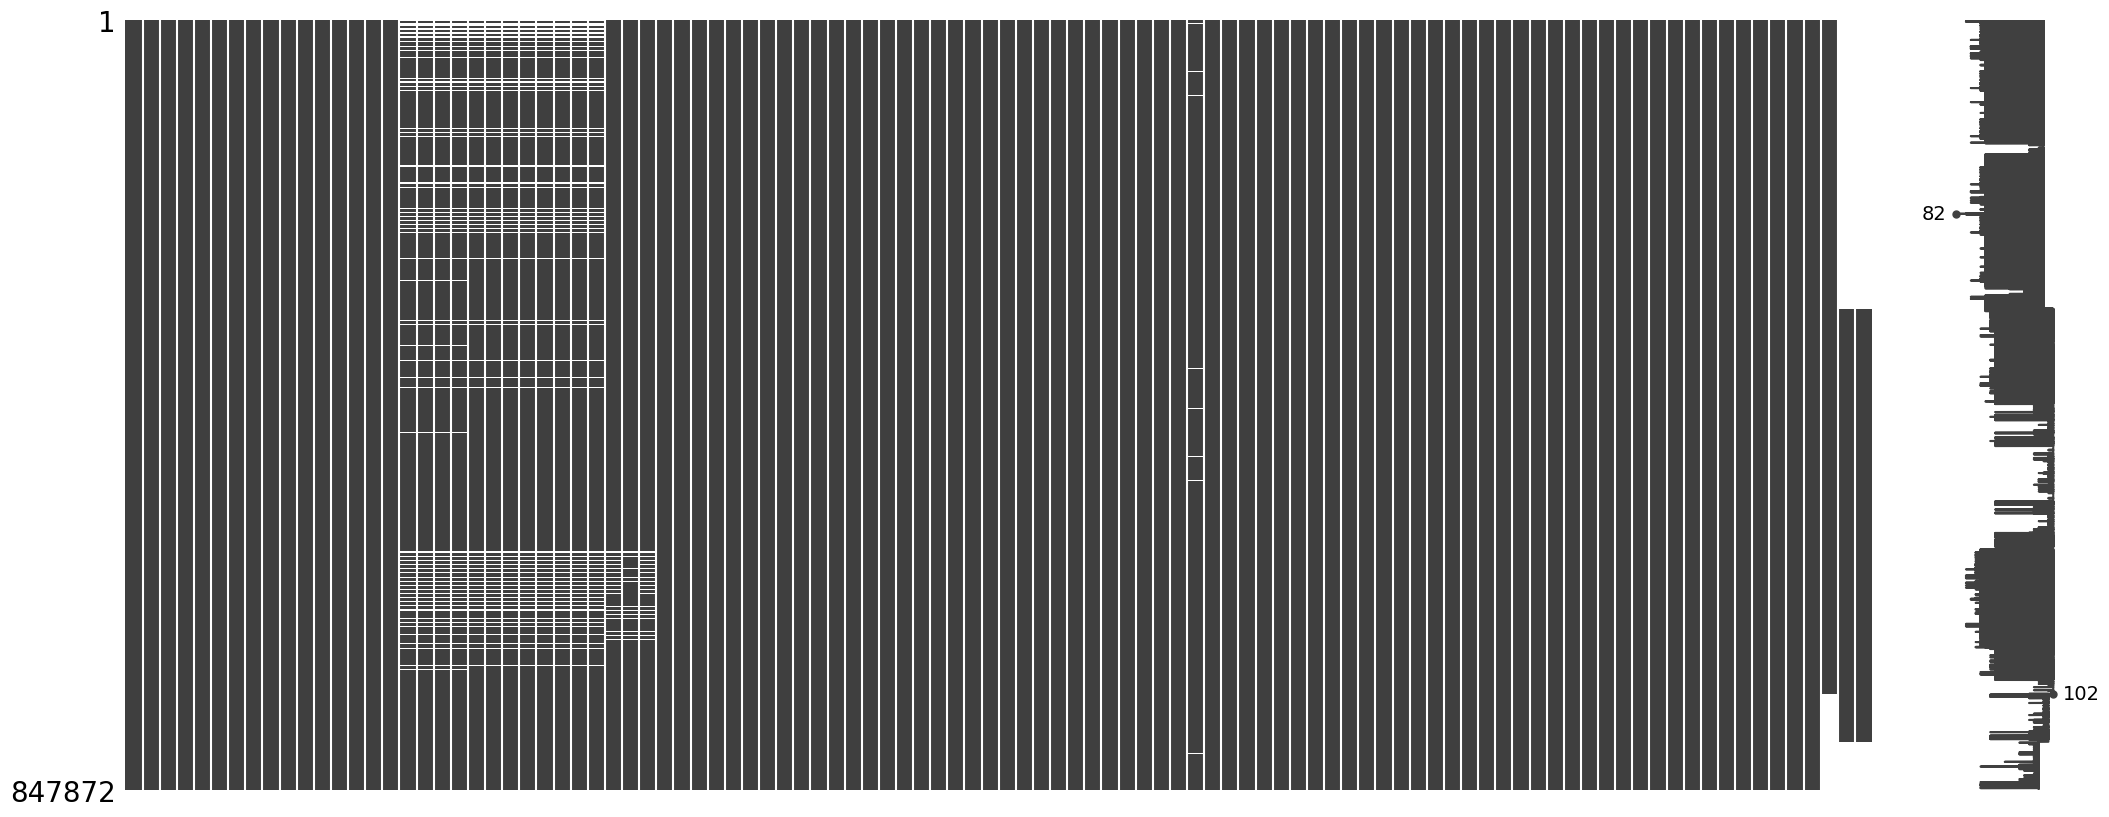

In [7]:
missingno.matrix(dataset_monthly)

In [8]:
missing = describe_dataframe(dataset_monthly, remove_zeros=True)
missing

,Column,Missing
16,ndvi,8.6540
17,ndmi,8.6540
18,ndwi,8.6540
19,ndbi,8.6540
20,ndvi_mean,7.9487
...,...,...
62,lc_prop2_assessment,1.6262
64,lc_prop3_assessment,0.3227
99,MIO_EUR,12.5000
100,L_TOTAL,43.7500


In [9]:
all_columns = dataset_monthly.columns.to_list()

In [10]:
len(dataset_monthly.columns)

102

In [11]:
desired_order = ['dt_placement','NUTS2_ID','NUTS2_NAME','NUTS3_ID','NUTS3_NAME','LAU1_NAME', 'cell_number', 'x','y','month','year',
 'ndvi','ndmi','ndwi','ndbi','ndvi_mean','ndmi_mean','ndwi_mean','ndbi_mean','ndvi_std','ndmi_std','ndwi_std','ndbi_std',
 'lst_day_mean','lst_jan_day_mean','lst_feb_day_mean','lst_mar_day_mean','lst_apr_day_mean',
 'lst_night_mean','lst_jan_night_mean','lst_feb_night_mean','lst_mar_night_mean','lst_apr_night_mean',
 'lst_mean','lst_jan_mean','lst_feb_mean','lst_mar_mean','lst_apr_mean','lst_min','lst_max',
 'rainfall_mean','acc_rainfall_1week','acc_rainfall_2week','acc_rainfall_month','acc_rainfall_jan',
 'bio1','bio2','bio3','bio4','bio5','bio6','bio7','bio8','bio9','bio10','bio11','bio12','bio13','bio14','bio15','bio16','bio17','bio18','bio19',
 'distance_to_coast','distance_to_river','slope_mean_1km','aspect_mean_200m','elevation_mean_1km','hillshade_mean_1km','fs_area_1km','flow_accu_200m',
 'lc_prop1','lc_prop1_assessment','lc_prop2','lc_prop2_assessment','lc_prop3','lc_prop3_assessment','lc_type1','lc_type2','lc_type3','lc_type4','lc_type5','lw','qc',
 'M_Y_LT15','M_Y15-64','M_Y_GE65','M_TOTAL','F_Y_LT15','F_Y15-64','F_Y_GE65','F_TOTAL','MIO_EUR','L_TOTAL','UNL_TOTAL',
 'MOUNT_TYPE', 'URBN_TYPE', 'COAST_TYPE',
 ]

In [12]:
len(desired_order)

99

In [13]:
diff1 = set(desired_order) - set(all_columns)
diff2 = set(all_columns) - set(desired_order)

# Combine the differences
result = list(diff1.union(diff2))

In [14]:
result

['rainfall_acc', 'NUTS1_ID', 'NUTS1_NAME']

In [15]:
dataset_monthly = dataset_monthly[desired_order].copy()

In [16]:
dataset_monthly

,dt_placement,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,LAU1_NAME,cell_number,x,y,month,year,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day_mean,lst_jan_day_mean,lst_feb_day_mean,lst_mar_day_mean,lst_apr_day_mean,lst_night_mean,lst_jan_night_mean,lst_feb_night_mean,lst_mar_night_mean,lst_apr_night_mean,lst_mean,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,lst_min,lst_max,rainfall_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_month,acc_rainfall_jan,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,lc_prop1,lc_prop1_assessment,lc_prop2,lc_prop2_assessment,lc_prop3,lc_prop3_assessment,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw,qc,M_Y_LT15,M_Y15-64,M_Y_GE65,M_TOTAL,F_Y_LT15,F_Y15-64,F_Y_GE65,F_TOTAL,MIO_EUR,L_TOTAL,UNL_TOTAL,MOUNT_TYPE,URBN_TYPE,COAST_TYPE
0,2009-01,EL52,κεντρικη μακεδονια,EL524,πελλα,εδεσσας,0,21.76334,40.79806,1,2009,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.748065,2.748065,6.860000,12.200323,19.997333,-4.917143,-4.917143,-2.108571,0.426774,6.3560,-0.811429,-1.084539,2.375714,6.313548,13.176667,-11.69,12.01,8.010621,29.589742,124.575643,236.225522,248.329258,14.000000,22.5,43.269231,835.300708,41.0,-11.0,52.0,5.666667,22.833333,24.333333,4.000000,1639.0,280.0,42.0,59.517557,741.0,204.0,301.0,586.0,1448.145975,456.840006,9,75.660308,748.319206,158.266121,0.0,1.000000,31,94.0,30,94.0,30,94.0,10,10,1,6,6,2,0,11214.0,44608.0,14535.0,70357.0,11089.0,43192.0,17464.0,71745.0,2046.51,NaN,NaN,2,3,2
1,2009-02,EL52,κεντρικη μακεδονια,EL524,πελλα,εδεσσας,0,21.76334,40.79806,2,2009,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.860000,2.748065,6.860000,12.200323,19.997333,-2.108571,-4.917143,-2.108571,0.426774,6.3560,2.375714,-1.084539,2.375714,6.313548,13.176667,-5.13,13.45,2.102109,2.040519,34.598660,63.375564,307.188321,14.000000,22.5,43.269231,835.300708,41.0,-11.0,52.0,5.666667,22.833333,24.333333,4.000000,1639.0,280.0,42.0,59.517557,741.0,204.0,301.0,586.0,1448.145975,456.840006,9,75.660308,748.319206,158.266121,0.0,1.000000,31,94.0,30,94.0,30,94.0,10,10,1,6,6,2,0,11214.0,44608.0,14535.0,70357.0,11089.0,43192.0,17464.0,71745.0,2046.51,NaN,NaN,2,3,2
2,2009-03,EL52,κεντρικη μακεδονια,EL524,πελλα,εδεσσας,0,21.76334,40.79806,3,2009,0.261058,-0.114798,-0.372435,0.114798,0.268055,-0.104575,-0.374817,0.104575,0.015541,0.022250,0.022234,0.022250,12.200323,2.748065,6.860000,12.200323,19.997333,0.426774,-4.917143,-2.108571,0.426774,6.3560,6.313548,-1.084539,2.375714,6.313548,13.176667,-3.61,19.47,2.777525,11.001492,31.057841,85.421364,393.291588,14.000000,22.5,43.269231,835.300708,41.0,-11.0,52.0,5.666667,22.833333,24.333333,4.000000,1639.0,280.0,42.0,59.517557,741.0,204.0,301.0,586.0,1448.145975,456.840006,9,75.660308,748.319206,158.266121,0.0,1.000000,31,94.0,30,94.0,30,94.0,10,10,1,6,6,2,0,11214.0,44608.0,14535.0,70357.0,11089.0,43192.0,17464.0,71745.0,2046.51,NaN,NaN,2,3,2
3,2009-04,EL52,κεντρικη μακεδονια,EL524,πελλα,εδεσσας,0,21.76334,40.79806,4,2009,0.205785,-0.093120,-0.304542,0.093120,0.217997,-0.099010,-0.321385,0.099010,0.034864,0.013892,0.027285,0.013892,19.997333,2.748065,6.860000,12.200323,19.997333,6.356000,-4.917143,-2.108571,0.426774,6.3560,13.176667,-1.084539,2.375714,6.313548,13.176667,1.13,26.51,3.001795,8.186157,74.191479,90.053839,483.345427,14.000000,22.5,43.269231,835.300708,41.0,-11.0,52.0,5.666667,22.833333,24.333333,4.000000,1639.0,280.0,42.0,59.517557,741.0,204.0,301.0,586.0,1448.145975,456.840006,9,75.660308,748.319206,158.266121,0.0,1.000000,31,94.0,30,94.0,30,94.0,10,10,1,6,6,2,0,11214.0,44608.0,14535.0,70357.0,11089.0,43192.0,17464.0,71745.0,2046.51,NaN,NaN,2,3,2
4,2009-05,EL52,κεντρικη μακεδονια,EL524,πελλα,εδεσσας,0,21.76334,40.79806,5,2009,0.363970,0.030331,-0.323501,-0.030331,0.337493,-0.008805,-0.336704,0.008805,0.046496,

In [17]:
years = dataset_monthly.year.unique()
months =  dataset_monthly.month.unique()
cell_codes = dataset_monthly.cell_number.unique()

In [18]:
data = []

for year in years[1:]:
    for month in months:
        print(f'Year: {year} | Month: {month}')
        for cell in cell_codes:
            df_regional = dataset_monthly.loc[(dataset_monthly['cell_number'] == cell)].copy()
            df_regional.reset_index(drop = True, inplace = True)

            df_prev_year = df_regional.loc[(df_regional['year'] == year-1)].copy()
            if month == 1:
                df_prev_month = df_regional.loc[(df_regional['year'] == year-1) & (df_regional['month'] == 12)].copy()
            else:
                df_prev_month = df_regional.loc[(df_regional['year'] == year) & (df_regional['month'] == month -1)].copy()

            df_curr_year = df_regional.loc[(df_regional['year'] == year) & (df_regional['month'] == month)].copy()
        
            data.append({'cell_number': cell,
                        'nuts2_id': df_curr_year.iloc[0]['NUTS2_ID'],
                        'nuts3_id': df_curr_year.iloc[0]['NUTS3_ID'],
                        'lau1': df_curr_year.iloc[0]['LAU1_NAME'], 
                        'year': year, 
                        'month': month,
                        'x' : df_curr_year.iloc[0]['x'],
                        'y': df_curr_year.iloc[0]['y'],
                        'ndvi': df_prev_month.iloc[0]['ndvi'],
                        'ndmi': df_prev_month.iloc[0]['ndmi'],
                        'ndwi': df_prev_month.iloc[0]['ndwi'],
                        'ndbi': df_prev_month.iloc[0]['ndbi'],
                        'ndvi_mean': df_prev_month.iloc[0]['ndvi_mean'],
                        'ndmi_mean': df_prev_month.iloc[0]['ndmi_mean'],
                        'ndwi_mean': df_prev_month.iloc[0]['ndwi_mean'],
                        'ndbi_mean': df_prev_month.iloc[0]['ndbi_mean'],
                        'ndvi_std': df_prev_month.iloc[0]['ndvi_std'],
                        'ndmi_std': df_prev_month.iloc[0]['ndmi_std'],
                        'ndwi_std': df_prev_month.iloc[0]['ndwi_std'],
                        'ndbi_std': df_prev_month.iloc[0]['ndbi_std'],

                        'lst_day_mean': df_prev_month.iloc[0]['lst_day_mean'],
                        'lst_jan_day_mean': df_curr_year.iloc[0]['lst_jan_day_mean'],
                        'lst_feb_day_mean': df_curr_year.iloc[0]['lst_feb_day_mean'],
                        'lst_mar_day_mean': df_curr_year.iloc[0]['lst_mar_day_mean'],
                        'lst_apr_day_mean': df_curr_year.iloc[0]['lst_apr_day_mean'],

                        'lst_night_mean': df_prev_month.iloc[0]['lst_night_mean'],
                        'lst_jan_night_mean': df_curr_year.iloc[0]['lst_jan_night_mean'],
                        'lst_feb_night_mean': df_curr_year.iloc[0]['lst_feb_night_mean'],
                        'lst_mar_night_mean': df_curr_year.iloc[0]['lst_mar_night_mean'],
                        'lst_apr_night_mean': df_curr_year.iloc[0]['lst_apr_night_mean'],

                        'lst_mean': df_prev_month.iloc[0]['lst_mean'],
                        'lst_jan_mean': df_curr_year.iloc[0]['lst_jan_mean'],
                        'lst_feb_mean': df_curr_year.iloc[0]['lst_feb_mean'],
                        'lst_mar_mean': df_curr_year.iloc[0]['lst_mar_mean'],
                        'lst_apr_mean': df_curr_year.iloc[0]['lst_apr_mean'],

                        'monthly_lst_min': df_prev_month.iloc[0]['lst_min'],
                        'monthly_lst_max': df_prev_month.iloc[0]['lst_max'],

                        'rainfall_mean': df_prev_month.iloc[0]['rainfall_mean'],
                        'acc_rainfall_1week': df_prev_month.iloc[0]['acc_rainfall_1week'],
                        'acc_rainfall_2week': df_prev_month.iloc[0]['acc_rainfall_2week'],
                        'acc_rainfall_month': df_prev_month.iloc[0]['acc_rainfall_month'],
                        'acc_rainfall_jan': df_curr_year.iloc[0]['acc_rainfall_jan'],

                        'bio1': df_prev_year.iloc[0]['bio1'],
                        'bio2': df_prev_year.iloc[0]['bio2'],
                        'bio3': df_prev_year.iloc[0]['bio3'],
                        'bio4': df_prev_year.iloc[0]['bio4'],
                        'bio5': df_prev_year.iloc[0]['bio5'],
                        'bio6': df_prev_year.iloc[0]['bio6'],
                        'bio7': df_prev_year.iloc[0]['bio7'],
                        'bio8': df_prev_year.iloc[0]['bio8'],
                        'bio9': df_prev_year.iloc[0]['bio9'],
                        'bio10': df_prev_year.iloc[0]['bio10'],
                        'bio11': df_prev_year.iloc[0]['bio11'],
                        'bio12': df_prev_year.iloc[0]['bio12'],
                        'bio13': df_prev_year.iloc[0]['bio13'],
                        'bio14': df_prev_year.iloc[0]['bio14'],
                        'bio15': df_prev_year.iloc[0]['bio15'],
                        'bio16': df_prev_year.iloc[0]['bio16'],
                        'bio17': df_prev_year.iloc[0]['bio17'],
                        'bio18': df_prev_year.iloc[0]['bio18'],
                        'bio19': df_prev_year.iloc[0]['bio19'],

                        'lc_prop1': df_curr_year.iloc[0]['lc_prop1'],
                        'lc_prop2': df_curr_year.iloc[0]['lc_prop2'],
                        'lc_prop3': df_curr_year.iloc[0]['lc_prop3'],
                        'lc_type1': df_curr_year.iloc[0]['lc_type1'],
                        'lc_type2': df_curr_year.iloc[0]['lc_type2'],
                        'lc_type3': df_curr_year.iloc[0]['lc_type3'],
                        'lc_type4': df_curr_year.iloc[0]['lc_type4'],
                        'lc_type5': df_curr_year.iloc[0]['lc_type5'],

                        'distance_to_coast': df_curr_year.iloc[0]['distance_to_coast'],
                        'distance_to_river': df_curr_year.iloc[0]['distance_to_river'],
                        'slope_mean_1km': df_curr_year.iloc[0]['slope_mean_1km'],
                        'aspect_mean_200m': df_curr_year.iloc[0]['aspect_mean_200m'],
                        'elevation_mean_1km': df_curr_year.iloc[0]['elevation_mean_1km'],
                        'hillshade_mean_1km': df_curr_year.iloc[0]['hillshade_mean_1km'],
                        'fs_area_1km': df_curr_year.iloc[0]['fs_area_1km'],
                        'flow_accu_200m': df_curr_year.iloc[0]['flow_accu_200m'],

                        'males_lt15': df_prev_year.iloc[0]['M_Y_LT15'],
                        'males_15t64': df_prev_year.iloc[0]['M_Y15-64'],
                        'males_gt65': df_prev_year.iloc[0]['M_Y_GE65'],
                        'males_total': df_prev_year.iloc[0]['M_TOTAL'],
                        'females_lt15': df_prev_year.iloc[0]['F_Y_LT15'],
                        'females_15t64': df_prev_year.iloc[0]['F_Y15-64'],
                        'females_gt65': df_prev_year.iloc[0]['F_Y_GE65'],
                        'females_total': df_prev_year.iloc[0]['F_TOTAL'],
                        'mio_eur': df_prev_year.iloc[0]['MIO_EUR'],
                        'l_total': df_prev_year.iloc[0]['L_TOTAL'],
                        'unl_total': df_prev_year.iloc[0]['UNL_TOTAL'],

                        'mount_type': df_prev_month.iloc[0]['MOUNT_TYPE'],
                        'urbn_type': df_prev_month.iloc[0]['URBN_TYPE'],
                        'coast_type': df_prev_month.iloc[0]['COAST_TYPE'],
                    
                        # 'cases': df_curr_year.iloc[0]['cases'],
                        })
        
dataset_operational = pd.DataFrame(data)       

Year: 2010 | Month: 1
Year: 2010 | Month: 2
Year: 2010 | Month: 3
Year: 2010 | Month: 4
Year: 2010 | Month: 5
Year: 2010 | Month: 6
Year: 2010 | Month: 7
Year: 2010 | Month: 8
Year: 2010 | Month: 9
Year: 2010 | Month: 10
Year: 2010 | Month: 11
Year: 2010 | Month: 12
Year: 2011 | Month: 1
Year: 2011 | Month: 2
Year: 2011 | Month: 3
Year: 2011 | Month: 4
Year: 2011 | Month: 5
Year: 2011 | Month: 6
Year: 2011 | Month: 7
Year: 2011 | Month: 8
Year: 2011 | Month: 9
Year: 2011 | Month: 10
Year: 2011 | Month: 11
Year: 2011 | Month: 12
Year: 2012 | Month: 1
Year: 2012 | Month: 2
Year: 2012 | Month: 3
Year: 2012 | Month: 4
Year: 2012 | Month: 5
Year: 2012 | Month: 6
Year: 2012 | Month: 7
Year: 2012 | Month: 8
Year: 2012 | Month: 9
Year: 2012 | Month: 10
Year: 2012 | Month: 11
Year: 2012 | Month: 12
Year: 2013 | Month: 1
Year: 2013 | Month: 2
Year: 2013 | Month: 3
Year: 2013 | Month: 4
Year: 2013 | Month: 5
Year: 2013 | Month: 6
Year: 2013 | Month: 7
Year: 2013 | Month: 8
Year: 2013 | Month: 9
Y

In [19]:
dataset_monthly[(dataset_monthly['cell_number'] == 0) & (dataset_monthly['year'] == 2017)].drop(columns=['NUTS2_ID','NUTS2_NAME','NUTS3_ID','LAU1_NAME'])

,dt_placement,NUTS3_NAME,cell_number,x,y,month,year,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day_mean,lst_jan_day_mean,lst_feb_day_mean,lst_mar_day_mean,lst_apr_day_mean,lst_night_mean,lst_jan_night_mean,lst_feb_night_mean,lst_mar_night_mean,lst_apr_night_mean,lst_mean,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,lst_min,lst_max,rainfall_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_month,acc_rainfall_jan,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,lc_prop1,lc_prop1_assessment,lc_prop2,lc_prop2_assessment,lc_prop3,lc_prop3_assessment,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw,qc,M_Y_LT15,M_Y15-64,M_Y_GE65,M_TOTAL,F_Y_LT15,F_Y15-64,F_Y_GE65,F_TOTAL,MIO_EUR,L_TOTAL,UNL_TOTAL,MOUNT_TYPE,URBN_TYPE,COAST_TYPE
423936,2017-01,πελλα,0,21.76334,40.79806,1,2017,0.309049,-0.093949,-0.291225,0.093949,0.296032,-0.096063,-0.285041,0.096063,0.016985,0.033386,0.016843,0.033386,3.481613,3.481613,9.942143,16.799032,21.175333,-2.502258,-2.502258,-3.708571,3.876452,5.038,0.489677,0.489677,3.116786,10.337742,13.106667,-12.37,8.09,3.717113,12.411311,69.819269,115.186849,115.230505,13.625,24.916667,43.71345,1052.513226,41.0,-16.0,57.0,1.666667,19.666667,26.666667,0.0,1245.0,284.0,38.0,66.775079,555.0,151.0,208.0,331.0,1448.145975,456.840006,9,75.660308,748.319206,158.266121,0.0,1.0,22,74.0,20,74.0,20,74.0,9,9,4,4,4,2,0,9893.0,43105.0,15149.0,68147.0,9443.0,42645.0,18348.0,70436.0,1620.04,4297.0,2496.0,2,3,2
423937,2017-02,πελλα,0,21.76334,40.79806,2,2017,0.308479,-0.095711,-0.291832,0.095711,0.295371,-0.097763,-0.285444,0.097763,0.016948,0.032865,0.016704,0.032865,9.942143,3.481613,9.942143,16.799032,21.175333,-3.708571,-2.502258,-3.708571,3.876452,5.038,3.116786,0.489677,3.116786,10.337742,13.106667,-16.05,18.41,2.160814,19.837339,21.484744,60.502786,175.733291,13.625,24.916667,43.71345,1052.513226,41.0,-16.0,57.0,1.666667,19.666667,26.666667,0.0,1245.0,284.0,38.0,66.775079,555.0,151.0,208.0,331.0,1448.145975,456.840006,9,75.660308,748.319206,158.266121,0.0,1.0,22,74.0,20,74.0,20,74.0,9,9,4,4,4,2,0,9893.0,43105.0,15149.0,68147.0,9443.0,42645.0,18348.0,70436.0,1620.04,4297.0,2496.0,2,3,2
423938,2017-03,πελλα,0,21.76334,40.79806,3,2017,0.303289,-0.131780,-0.310015,0.131780,0.288830,-0.131917,-0.300126,0.131917,0.018152,0.023374,0.014461,0.023374,16.799032,3.481613,9.942143,16.799032,21.175333,3.876452,-2.502258,-3.708571,3.876452,5.038,10.337742,0.489677,3.116786,10.337742,13.106667,0.33,27.41,2.721748,1.887299,4.787975,63.877216,260.107482,13.625,24.916667,43.71345,1052.513226,41.0,-16.0,57.0,1.666667,19.666667,26.666667,0.0,1245.0,284.0,38.0,66.775079,555.0,151.0,208.0,331.0,1448.145975,456.840006,9,75.660308,748.319206,158.266121,0.0,1.0,22,74.0,20,74.0,20,74.0,9,9,4,4,4,2,0,9893.0,43105.0,15149.0,68147.0,9443.0,42645.0,18348.0,70436.0,1620.04,4297.0,2496.0,2,3,2
423939,2017-04,πελλα,0,21.76334,40.79806,4,2017,0.328463,-0.081889,-0.326864,0.081889,0.319196,-0.077346,-0.323261,0.077346,0.030430,0.032091,0.018107,0.032091,21.175333,3.481613,9.942143,16.799032,21.175333,5.038000,-2.502258,-3.708571,3.876452,5.038,13.106667,0.489677,3.116786,10.337742,13.106667,-4.43,28.07,1.890473,18.636660,24.226872,56.714193,316.821675,13.625,24.916667,43.71345,1052.513226,41.0,-16.0,57.0,1.666667,19.666667,26.666667,0.0,1245.0,284.0,38.0,66.775079,555.0,151.0,208.0,331.0,1448.145975,456.840006,9,75.660308,748.319206,158.266121,0.0,1.0,22,74.0,20,74.0,20,74.0,9,9,4,4,4,2,0,9893.0,43105.0,15149.0,68147.0,9443.0,42645.0,18348.0,70436.0,1620.04,4297.0,2496.0,2,3,2
423940,2017-05,πελλα,0,21.76334,40.79806,5,2017,0.326355,0.304048,-0.281833,-0.304048,0.410773,0.259706,-0.347347,-0.259706,0.048771,0.047147,0.034800,0.047147,25.750000,3.481613,9.942143,16.799032,21.175333,12.761613,-2.502258,-3.708571,

In [20]:
dataset_operational[(dataset_operational['cell_number'] == 0) & (dataset_operational['year'] == 2018)]

,cell_number,nuts2_id,nuts3_id,lau1,year,month,x,y,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day_mean,lst_jan_day_mean,lst_feb_day_mean,lst_mar_day_mean,lst_apr_day_mean,lst_night_mean,lst_jan_night_mean,lst_feb_night_mean,lst_mar_night_mean,lst_apr_night_mean,lst_mean,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,monthly_lst_min,monthly_lst_max,rainfall_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_month,acc_rainfall_jan,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,males_lt15,males_15t64,males_gt65,males_total,females_lt15,females_15t64,females_gt65,females_total,mio_eur,l_total,unl_total,mount_type,urbn_type,coast_type
423936,0,EL52,EL524,εδεσσας,2018,1,21.76334,40.79806,0.313319,-0.080928,-0.300870,0.080928,0.297286,-0.090610,-0.287572,0.090610,0.022688,0.035234,0.018563,0.035234,7.833871,7.635806,8.97,14.336452,25.177333,0.300323,0.506774,-0.205714,1.289355,10.158667,4.067097,4.07129,4.382143,7.812903,17.668,-9.93,11.87,5.034564,3.981100,19.292321,52.512288,69.254835,13.625,24.916667,43.71345,1052.513226,41.0,-16.0,57.0,1.666667,19.666667,26.666667,0.0,1245.0,284.0,38.0,66.775079,555.0,151.0,208.0,331.0,22,20,20,9,9,4,4,4,1448.145975,456.840006,9,75.660308,748.319206,158.266121,0.0,1.0,9893.0,43105.0,15149.0,68147.0,9443.0,42645.0,18348.0,70436.0,1620.04,4297.0,2496.0,2,3,2
428352,0,EL52,EL524,εδεσσας,2018,2,21.76334,40.79806,0.319202,-0.086139,-0.310332,0.086139,0.297922,-0.092702,-0.291458,0.092702,0.023501,0.038212,0.020091,0.038212,7.635806,7.635806,8.97,14.336452,25.177333,0.506774,0.506774,-0.205714,1.289355,10.158667,4.071290,4.07129,4.382143,7.812903,17.668,-3.85,12.31,2.234027,0.000000,8.442638,69.226505,322.818751,13.625,24.916667,43.71345,1052.513226,41.0,-16.0,57.0,1.666667,19.666667,26.666667,0.0,1245.0,284.0,38.0,66.775079,555.0,151.0,208.0,331.0,22,20,20,9,9,4,4,4,1448.145975,456.840006,9,75.660308,748.319206,158.266121,0.0,1.0,9893.0,43105.0,15149.0,68147.0,9443.0,42645.0,18348.0,70436.0,1620.04,4297.0,2496.0,2,3,2
432768,0,EL52,EL524,εδεσσας,2018,3,21.76334,40.79806,0.236966,-0.029234,-0.190846,0.029234,0.248994,-0.068811,-0.234002,0.068811,0.045599,0.050486,0.079280,0.050486,8.970000,7.635806,8.97,14.336452,25.177333,-0.205714,0.506774,-0.205714,1.289355,10.158667,4.382143,4.07129,4.382143,7.812903,17.668,-8.91,11.45,9.055854,17.673727,74.342291,253.563917,544.918971,13.625,24.916667,43.71345,1052.513226,41.0,-16.0,57.0,1.666667,19.666667,26.666667,0.0,1245.0,284.0,38.0,66.775079,555.0,151.0,208.0,331.0,22,20,20,9,9,4,4,4,1448.145975,456.840006,9,75.660308,748.319206,158.266121,0.0,1.0,9893.0,43105.0,15149.0,68147.0,9443.0,42645.0,18348.0,70436.0,1620.04,4297.0,2496.0,2,3,2
437184,0,EL52,EL524,εδεσσας,2018,4,21.76334,40.79806,0.262942,0.010000,-0.258764,-0.010000,0.237641,0.013810,-0.238012,-0.013810,0.055625,0.079659,0.060062,0.079659,14.336452,7.635806,8.97,14.336452,25.177333,1.289355,0.506774,-0.205714,1.289355,10.158667,7.812903,4.07129,4.382143,7.812903,17.668,-7.93,22.57,7.164523,12.133546,72.854002,207.481879,571.530628,13.625,24.916667,43.71345,1052.513226,41.0,-16.0,57.0,1.666667,19.666667,26.666667,0.0,1245.0,284.0,38.0,66.775079,555.0,151.0,208.0,331.0,22,20,20,9,9,4,4,4,1448.145975,456.840006,9,75.660308,748.319206,158.266121,0.0,1.0,9893.0,43105.0,15149.0,68147.0,9443.0,42645.0,18348.0,70436.0,1620.04,4297.0,2496.0,2,3,2
441600,0,EL52,EL524,εδεσσας,2018,5,21.76334,40.79806,0.408381,-0.065172,-0.369258,0.065172,0.357442,-0.025376,-0.313345,0.025376,0.041805,0.049805,0.040286,0.049805,25.177333,7.635806,8.97,14.336452,25.177333,10.158667,0.506774,-0.205714,1.289355,10.158667,17.668000,4.07129,4.382143,7.812903,17.668,4.01,32.27,0.887055,8.326400,8.693120,26.611

<Axes: >

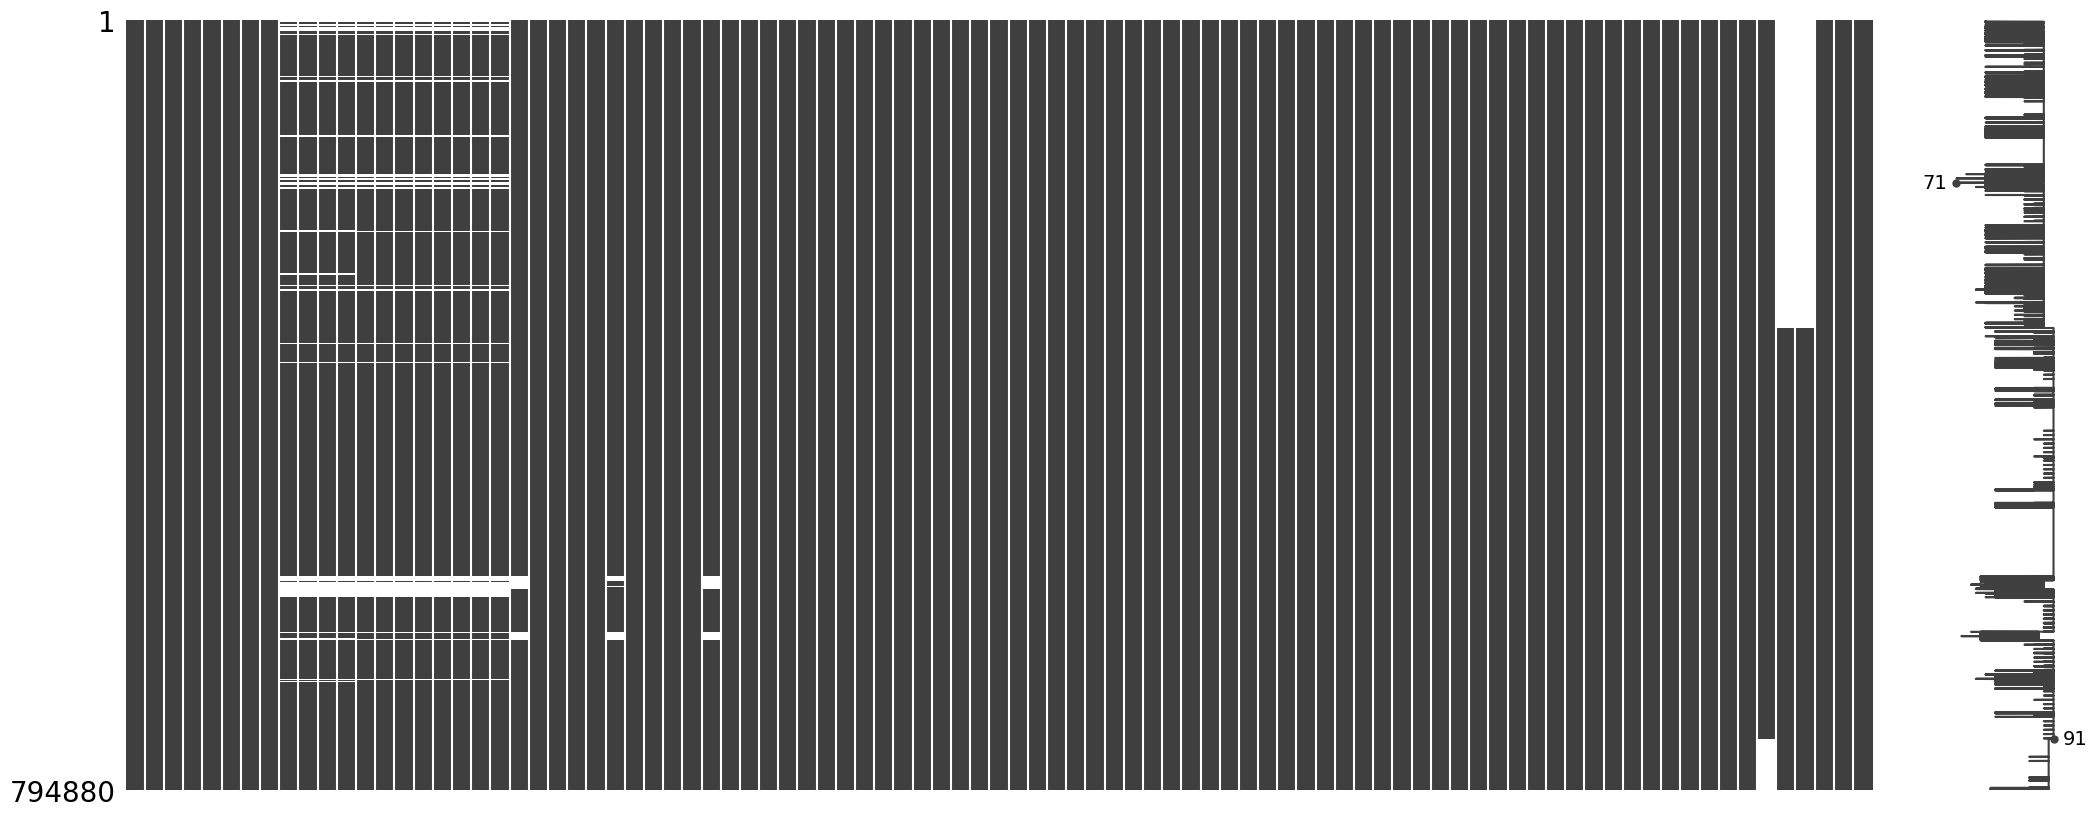

In [21]:
missingno.matrix(dataset_operational)

In [22]:
missing = describe_dataframe(dataset_operational, remove_zeros=True)
missing

,Column,Missing
8,ndvi,7.5537
9,ndmi,7.5537
10,ndwi,7.5537
11,ndbi,7.5537
12,ndvi_mean,6.8486
...,...,...
32,lst_feb_mean,0.0257
33,lst_mar_mean,0.0045
85,mio_eur,6.6667
86,l_total,40.0000


In [23]:
# dataset_monthly.cases.sum()

In [24]:
# dataset_operational.cases.sum()

In [25]:
years = dataset_operational.year.unique().tolist()

In [26]:
for item in years:
    dataset_operational[dataset_operational.year == item].to_csv(f"../../data/{NUTS2}/{NUTS0}_{NUTS2}_WNV_Dataset_GRID_OP_{item}.csv", encoding = enc, index = False)